# Recreating Denby (1988)'s own worked example

B. Denby's 1988 paper introduces its Hopfield-network track finder with one
concrete figure: a scanned 4-track event on a 13-layer detector (fig. 8(a)).
`tracking/denby` reverse-engineers that exact detector and event from the
paper's own figure (as an SVG trace), re-simulates it through `detectorsim2d`
to validate the geometry, and then runs `hopfield_tracking` — a from-scratch
reimplementation of the paper's actual algorithm — on it, watching the
network relax into the same answer from a random start instead of drawing
the known one.

This notebook walks the same pipeline the package's own scripts run, as one
narrative: harmonize the detector -> fit the event -> re-simulate and
validate -> run the Hopfield network -> (briefly) a systematic multiplicity
sweep. Everything stays in the reference figure's own SVG pixel coordinate
system (`y` grows downward, `viewBox="0 0 924 1074"`) so results overlay the
original directly, with no rescaling.


In [1]:
%matplotlib inline
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import SVG, display

DENBY = "../aihep/tracking/denby"
sys.path.insert(0, f"{DENBY}/python")  # the shared denby_svg.py helper module

from denby_svg import (
    derive_vertex, parse_layer_lines, parse_event_tracks,
    fit_circle_to_svg_path, sample_cubic_path, extract_svg_body,
)
from detector2d.geometry import LineLayer
from detectorsim2d.edm import PARTICLES_COLUMNS
from detectorsim2d.vis import export_svg, plot_event, LAYER_COLOR, HIT_COLOR
from detectorsim2d.simulate import hits_for_particles
from viz_style.mpl import style_axes

from hopfield_tracking.cli import run as hopfield_run, DEFAULT_R_C_FACTOR
from hopfield_tracking.network import build_segments, mean_consecutive_hit_distance
from hopfield_tracking.vis import plot_iterations

PITCH = 10.0  # arbitrary digitization cell size along each layer, in original px units

## 1. Harmonize the detector

The reference figure's 13 red dashed detection-plane lines already share
one length (709.521 px) but vary slightly in left-edge x and vertical
spacing (53-60 px, mean 58.32). We re-derive those numbers straight from
the SVG — nothing hardcoded — and build 13 identical, equidistant
`LineLayer`s.


In [2]:
detector_svg = open(f"{DENBY}/resources/denby_detector.svg").read()
event_svg = open(f"{DENBY}/resources/denby_detector_event.svg").read()

original = parse_layer_lines(detector_svg)
n = len(original)
y_first, y_last = original[0][1], original[-1][1]
spacing = (y_last - y_first) / (n - 1)
x1 = min(x1 for x1, _, _, _ in original)
length = sum(x2 - x1 for x1, _, x2, _ in original) / n  # already ~equal; average for robustness
x2 = x1 + length

layers = [
    LineLayer(layer_id=i, p1=(x1, y_first + i * spacing), p2=(x2, y_first + i * spacing), pitch=PITCH)
    for i in range(n)
]
print(f"{len(layers)} layers, spacing={spacing:.3f}px, length={layers[0].length:.3f}px")


13 layers, spacing=58.322px, length=709.521px


The 4 blue dashed tracks in the event figure are genuine circular arcs
(confirmed by an essentially-exact circle fit). Every pair's fitted circle
intersects at the same point — the green marker dot turns out not to be
decoration, but the point source. `derive_vertex` computes both (marker
center, and pairwise circle-circle intersection) and raises if they
disagree by more than a few pixels.


In [3]:
vertex_x, vertex_y = derive_vertex(event_svg)
print(f"point source: ({vertex_x:.2f}, {vertex_y:.2f})")


point source: (424.25, 894.54)


Note `vertex_y ~ 895` is *below* the layer stack (`y` spans ~70-770) — the
tracks fly upward through the detector, not downward, since SVG `y` grows
downward.


## 2. Fit the event

For each of the 4 tracks, recover `(x0, y0, phi0, charge, radius)` directly
in the SVG's own pixel coordinate system. `(x0, y0)` is the shared derived
vertex. The interesting step is disambiguating *which* of the two possible
curl directions at the vertex is the right one: we pick whichever one's
forward sweep reaches the track's farthest-from-vertex sampled point the
short way around — the only sensible choice for a track drawn as one
non-looping arc. `charge` (`+1` CCW, `-1` CW) is then a **convention**, not
a measurement: flipping the assumed field direction would flip every charge
and leave the picture identical.


In [4]:
def resolve_direction_and_radius(vertex, far_point, center, r_geom):
    x0, y0 = vertex
    cx, cy = center
    theta_vertex = math.atan2(y0 - cy, x0 - cx)
    theta_far = math.atan2(far_point[1] - cy, far_point[0] - cx)
    forward_sweep_if_ccw = (theta_far - theta_vertex) % (2 * math.pi)
    forward_sweep_if_cw = (theta_vertex - theta_far) % (2 * math.pi)
    radius = r_geom if forward_sweep_if_ccw <= forward_sweep_if_cw else -r_geom
    phi0 = math.atan2((x0 - cx) / radius, (cy - y0) / radius)
    return phi0, radius


def fit_track(d, vertex):
    points = sample_cubic_path(d)
    cx, cy, r_geom = fit_circle_to_svg_path(d)
    far_index = int(np.argmax(np.hypot(points[:, 0] - vertex[0], points[:, 1] - vertex[1])))
    far_point = tuple(points[far_index])
    phi0, radius = resolve_direction_and_radius(vertex, far_point, (cx, cy), r_geom)
    charge = 1.0 if radius > 0 else -1.0
    return dict(x0=vertex[0], y0=vertex[1], phi0=phi0, charge=charge, radius=radius)


vertex = (vertex_x, vertex_y)
rows = [
    dict(event_id=0, particle_id=pid, **fit_track(d, vertex))
    for pid, d in enumerate(parse_event_tracks(event_svg))
]
particles = pd.DataFrame(rows, columns=PARTICLES_COLUMNS)
particles[["particle_id", "x0", "y0", "phi0", "charge", "radius"]]


,particle_id,x0,y0,phi0,charge,radius
0,0,424.25,894.536009,-1.739903,-1.0,-6375.243849
1,1,424.25,894.536009,-1.202904,1.0,1920.297015
2,2,424.25,894.536009,-2.059336,1.0,639.811358
3,3,424.25,894.536009,-1.331239,-1.0,-2213.785064


## 3. Re-simulate and validate

Feed the fitted `particles` and harmonized `layers` through the exact same
`detectorsim2d.simulate.hits_for_particles` any other `detectorsim2d`
consumer would use, then compare against the original reference figure.


Building that picture up in stages makes clear what the Hopfield network in
section 4 actually has to solve: an empty detector, then the raw digitized
hits with no structure at all, then the full combinatorial graph connecting
every hit to every other hit on a *different* layer within the network's own
locality cut `R_c` (same-layer pairs are never valid segments — a real track
crosses each plane once) — and only then the ground-truth trajectories
themselves.


49 hits across 13 layers for 4 particles


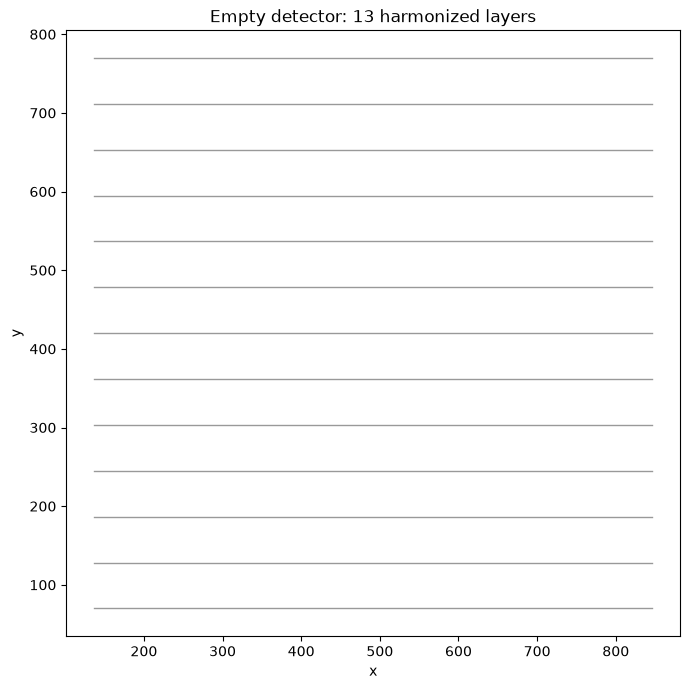

In [5]:
def plot_layers_and_hits(layers, hits=None, segments=None, title=""):
    """A stripped-down event display, sharing `plot_event`'s layer/hit
    styling but decoupled from per-particle trajectories, so the detector,
    the hits, and the candidate graph can each be shown on their own."""
    fig, ax = plt.subplots(figsize=(7, 7))
    for layer in layers:
        (x1, y1), (x2, y2) = layer.p1, layer.p2
        ax.plot([x1, x2], [y1, y2], color=LAYER_COLOR, linewidth=1.0, zorder=1)
    if segments is not None:
        for seg in segments:
            sx, sy = seg.start_xy
            ex, ey = seg.end_xy
            ax.plot([sx, ex], [sy, ey], color=HIT_COLOR, linewidth=0.4, alpha=0.4, zorder=2)
    if hits is not None and len(hits):
        ax.scatter(hits["x"], hits["y"], color=HIT_COLOR, s=15, zorder=4)
    ax.set_aspect("equal")
    style_axes(ax, spatial=True, title=title, xlabel="x", ylabel="y")
    fig.tight_layout()
    return fig


hits = hits_for_particles(particles, layers)
print(f"{len(hits)} hits across {len(layers)} layers for {len(particles)} particles")

fig = plot_layers_and_hits(layers, title="Empty detector: 13 harmonized layers")

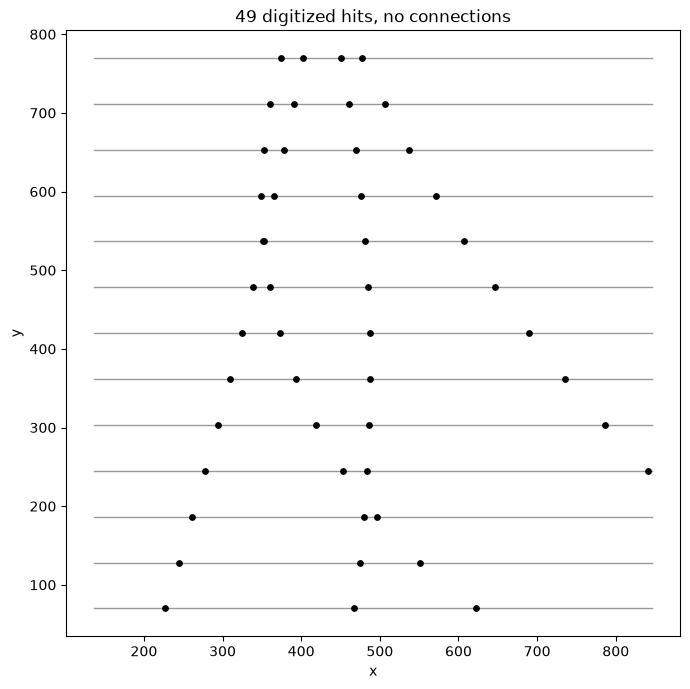

In [6]:
fig = plot_layers_and_hits(layers, hits=hits, title=f"{len(hits)} digitized hits, no connections")

144 candidate segments (R_c=95.27px, different layers only)


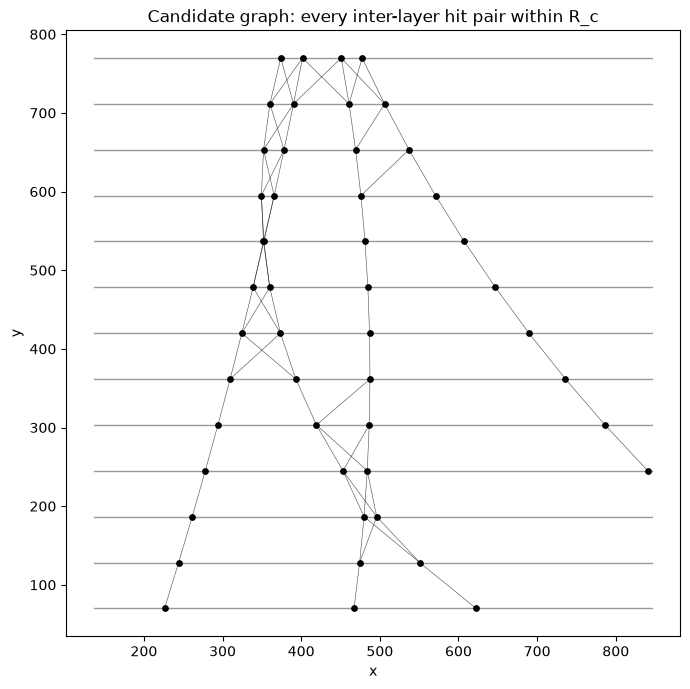

In [7]:
mean_r = mean_consecutive_hit_distance(hits)
r_c = DEFAULT_R_C_FACTOR * mean_r
candidate_segments = build_segments(
    hits["x"].to_numpy(), hits["y"].to_numpy(), r_c, layer_ids=hits["layer_id"].to_numpy()
)
print(f"{len(candidate_segments)} candidate segments (R_c={r_c:.2f}px, different layers only)")

fig = plot_layers_and_hits(
    layers, hits=hits, segments=candidate_segments,
    title="Candidate graph: every inter-layer hit pair within R_c",
)

Text(0.5, 0.98, 'Re-simulated event, harmonized detector')

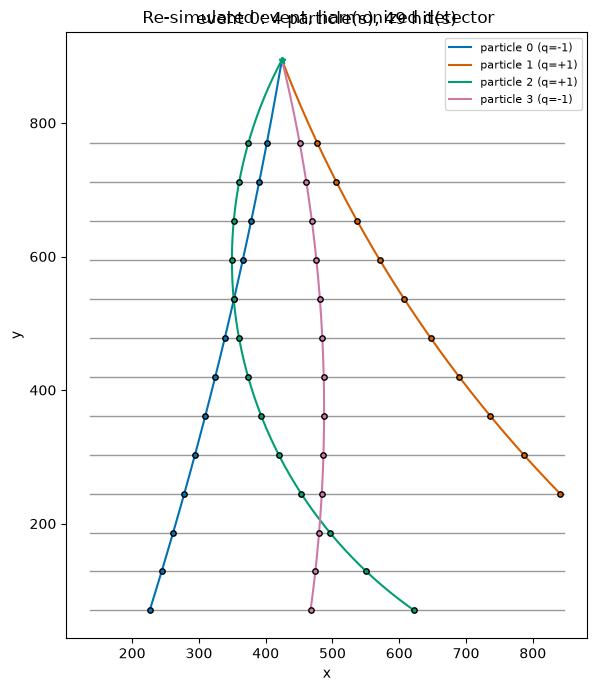

In [8]:
fig = plot_event(particles, hits, layers, event_id=0)
fig.suptitle("Re-simulated event, harmonized detector")

And the objective check: overlay the re-simulated event (solid) on top of
the original reference figure (dimmed) in the exact same coordinate system.


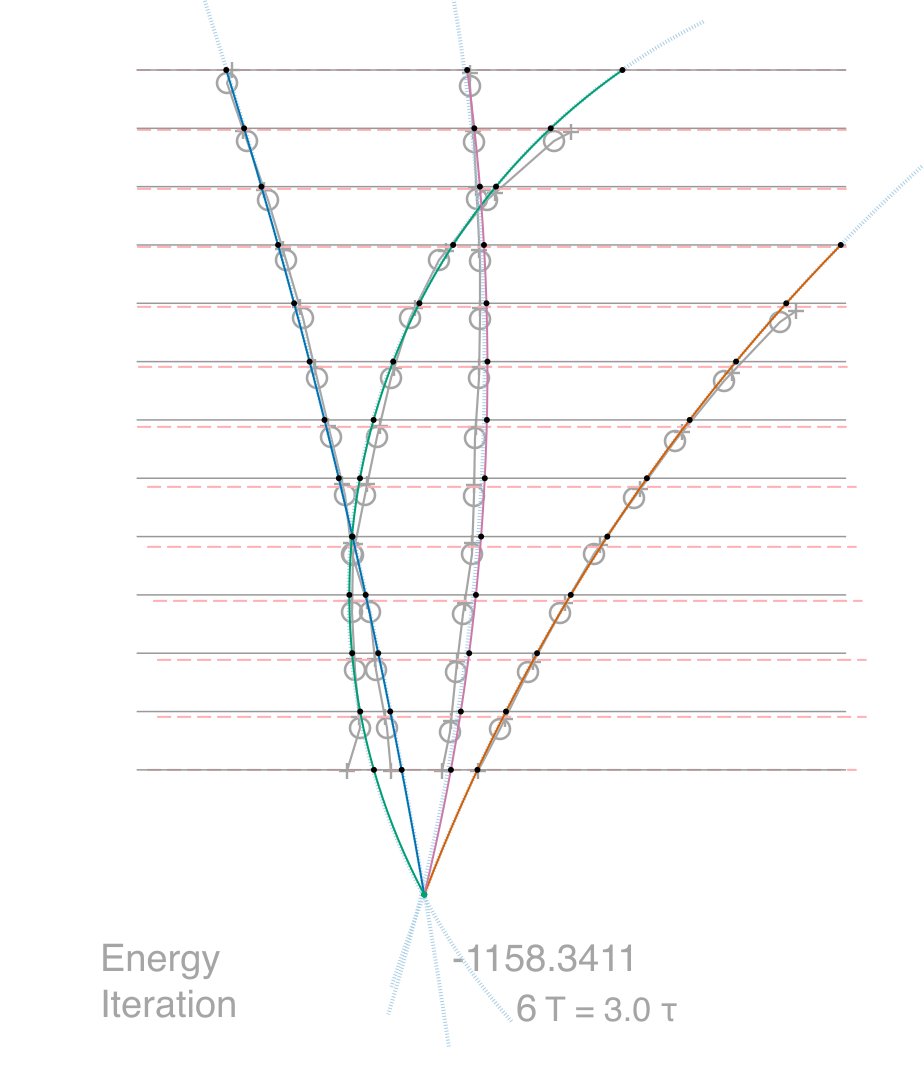

In [9]:
reference_body = extract_svg_body(event_svg)
export_svg(
    layers, particles, hits, "/tmp/denby_overlay_notebook.svg",
    width=924.0, height=1074.0,
    extra_svg=(f'<g id="reference" opacity="0.35">{reference_body}</g>',),
)
display(SVG(filename="/tmp/denby_overlay_notebook.svg"))


All 4 simulated tracks trace almost exactly over the original dashed ones —
typically under 3px of residual on this ~1000px-wide figure, despite the
harmonized layer y-positions differing slightly from the original's
irregular spacing.


## 4. Running the Hopfield network itself

Everything above reproduces fig. 8(a) *geometrically* — drawing the tracks
the network eventually converges to (the event figure's own "Energy
-1158.3411 / Iteration 6" annotation matches the paper's fig. 8(a) last
frame exactly). `hopfield_tracking` is the natural next step: instead of
drawing the known answer, start from a random state and watch the network
relax into it.

`hopfield_tracking` only ever needs a plain `(particle_id, layer_id, x, y)`
table — `layer_id` is what lets it exclude same-layer candidate segments
(two hits on one plane can never be the two ends of one physical segment).


144 candidate segments, converged in 50 iterations
score: {'n_true_tracks': 4, 'n_found_chains': 4, 'n_exact_matches': 2, 'perfect': False}


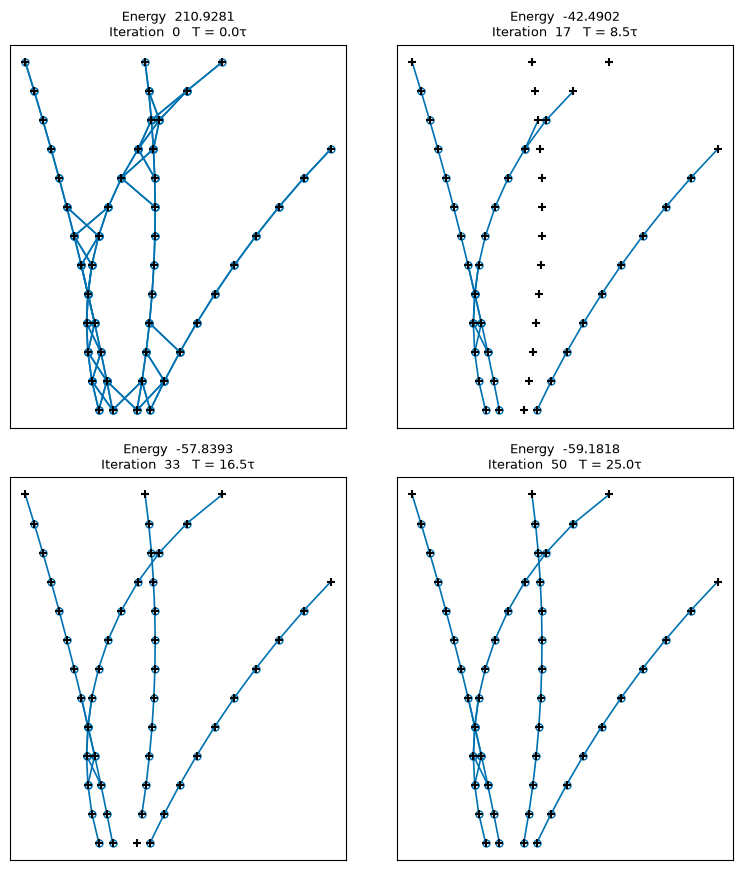

In [10]:
hopfield_hits = hits[["particle_id", "layer_id", "x", "y"]].reset_index(drop=True)

segments, history, chains, score = hopfield_run(hopfield_hits, seed=3)  # seed=3: typical of the mean outcome
print(f"{len(segments)} candidate segments, converged in {len(history) - 1} iterations")
print("score:", score)

xy = hopfield_hits[["x", "y"]].to_numpy()
fig = plot_iterations(xy, segments, history)


Starting from random noise, the network reliably reconstructs 2 of the 4
tracks exactly and the other 2 correctly along their outer ~8 of 13 hits,
with confusion in their innermost hits — precisely where all 4 tracks pass
closest together, right after the shared vertex. This is a smaller-scale
echo of what the paper itself says about its harder fig. 8(b) case:
*"confusion in regions where tracks are very close together."* Here that
region is the vertex itself, since (unlike a typical two-tracks-crossing
case) all 4 tracks in this event originate from one shared point.


## 5. A systematic multiplicity sweep

Is the vertex-crowding confusion above a one-off, or does reconstruction
quality systematically degrade as more tracks compete for the same hits?
`tracking/denby` answers this by generating a batch of synthetic 1-6-track
events sharing the same vertex (`generate_random_events.py`, reusing
`detectorsim2d`'s particle-gun simulation) and running the network on every
one of them (`run_hopfield_sweep.py`). The results are checked in —
loading them directly here rather than regenerating (15 events per
multiplicity, ~90 total):


In [11]:
sweep = pd.read_csv(f"{DENBY}/resources/denby_sweep_results.csv")
summary = sweep.groupby("multiplicity").agg(
    n_events=("event_id", "size"),
    perfect_rate=("perfect", "mean"),
    mean_exact_matches=("n_exact_matches", "mean"),
)
summary


,n_events,perfect_rate,mean_exact_matches
multiplicity,,,
1,15,1.000000,1.000000
2,15,0.000000,0.666667
3,15,0.066667,1.266667
4,15,0.000000,0.866667
5,15,0.000000,1.066667
6,15,0.000000,1.000000


Text(0.5, 1.0, 'Hopfield network: reconstruction quality vs. track multiplicity')

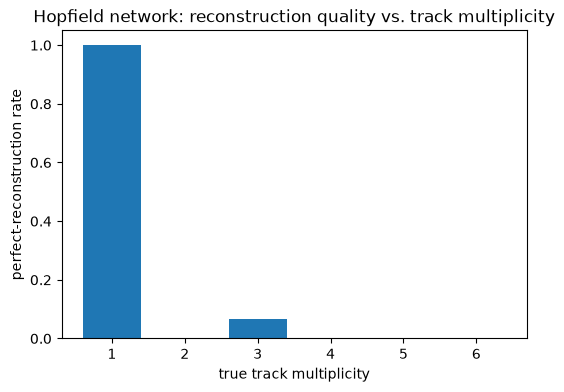

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(summary.index.astype(str), summary["perfect_rate"], color="tab:blue")
ax.set_xlabel("true track multiplicity")
ax.set_ylabel("perfect-reconstruction rate")
ax.set_title("Hopfield network: reconstruction quality vs. track multiplicity")


The 1-track case reconstructs perfectly every time (trivial: nothing to
confuse); reconstruction quality falls off sharply once multiple tracks
share the vertex — the quantitative, systematic version of the paper's
qualitative fig. 8(a) (perfect) vs. fig. 8(b) (confused) contrast.
